#### Importing the Required Libraries

In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import tensorflow
import pytorch_lightning as pl
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE

from lightning.pytorch import Trainer, LightningModule
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor
)
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet, QuantileLoss
from captum.attr import IntegratedGradients
import shap
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pytorch_forecasting.models import RecurrentNetwork
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
import optuna
from pytorch_lightning import Trainer
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Importing and shaping the required data

In [2]:
germany_cleaned_data = pd.read_csv('cleaned_germany_energy_weather.csv', parse_dates=['utc_timestamp'])
germany_cleaned_data = germany_cleaned_data.drop(columns='Unnamed: 0')
germany_cleaned_data['country'] = 'Germany'
germany_cleaned_data['is_Germany'] = 1
germany_cleaned_data['is_UK'] = 0

In [3]:
germany_cleaned_data.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_wind_generation_actual,DE_wind_onshore_generation_actual,DE_wind_offshore_generation_actual,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0
1,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0
2,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0
3,2015-01-01 02:00:00,39106.0,37248.0,71.0,9070.0,8552.0,518.0,3.3,0.0,14.6,Germany,1,0
4,2015-01-01 03:00:00,38765.0,37248.0,71.0,9163.0,8643.0,520.0,3.0,0.0,14.1,Germany,1,0


In [4]:
germany_cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   utc_timestamp                       50401 non-null  datetime64[ns]
 1   DE_load_actual_entsoe_transparency  50401 non-null  float64       
 2   DE_solar_capacity                   50401 non-null  float64       
 3   DE_solar_generation_actual          50401 non-null  float64       
 4   DE_wind_generation_actual           50401 non-null  float64       
 5   DE_wind_onshore_generation_actual   50401 non-null  float64       
 6   DE_wind_offshore_generation_actual  50401 non-null  float64       
 7   temperature_2m                      50401 non-null  float64       
 8   shortwave_radiation                 50401 non-null  float64       
 9   windspeed_10m                       50401 non-null  float64       
 10  country               

In [5]:
uk_cleaned_data = pd.read_csv('cleaned_uk_energy_weather.csv', parse_dates=['utc_timestamp'])
uk_cleaned_data = uk_cleaned_data.drop(columns='Unnamed: 0')
uk_cleaned_data['country'] = 'UK'
uk_cleaned_data['is_Germany'] = 0
uk_cleaned_data['is_UK'] = 1

In [6]:
uk_cleaned_data.head()

,utc_timestamp,GB_GBN_load_actual_entsoe_transparency,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_wind_generation_actual,GB_GBN_wind_onshore_generation_actual,GB_GBN_wind_offshore_generation_actual,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,26758.0,2664.0,13.0,782.0,664.0,117.0,4.7,0.0,20.3,UK,0,1
1,2015-01-01 00:00:00,26758.0,2669.0,13.0,782.0,664.0,117.0,4.7,0.0,21.1,UK,0,1
2,2015-01-01 01:00:00,27166.0,2669.0,13.0,782.0,664.0,117.0,5.0,0.0,20.6,UK,0,1
3,2015-01-01 02:00:00,24472.0,2669.0,13.0,785.0,666.0,120.0,5.3,0.0,19.9,UK,0,1
4,2015-01-01 03:00:00,23003.0,2669.0,13.0,776.0,662.0,115.0,5.7,0.0,18.7,UK,0,1


In [7]:
uk_cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   utc_timestamp                           50401 non-null  datetime64[ns]
 1   GB_GBN_load_actual_entsoe_transparency  50401 non-null  float64       
 2   GB_GBN_solar_capacity                   50401 non-null  float64       
 3   GB_GBN_solar_generation_actual          50401 non-null  float64       
 4   GB_GBN_wind_generation_actual           50401 non-null  float64       
 5   GB_GBN_wind_onshore_generation_actual   50401 non-null  float64       
 6   GB_GBN_wind_offshore_generation_actual  50401 non-null  float64       
 7   temperature_2m                          50401 non-null  float64       
 8   shortwave_radiation                     50401 non-null  float64       
 9   windspeed_10m                           50401 non-

In [8]:
germany_column_map = {
  'DE_load_actual_entsoe_transparency':'load_actual',
  'DE_solar_capacity':'solar_capacity',
  'DE_solar_generation_actual':'solar_generation',
  'DE_wind_generation_actual':'wind_generation',
  'DE_wind_onshore_generation_actual':'wind_onshore',
  'DE_wind_offshore_generation_actual':'wind_offshore',
}
uk_column_map = {
  'GB_GBN_load_actual_entsoe_transparency':'load_actual',
  'GB_GBN_solar_capacity':'solar_capacity',
  'GB_GBN_solar_generation_actual':'solar_generation',
  'GB_GBN_wind_generation_actual':'wind_generation',
  'GB_GBN_wind_onshore_generation_actual':'wind_onshore',
  'GB_GBN_wind_offshore_generation_actual':'wind_offshore',
}

In [9]:
germany_cleaned_data_renamed = germany_cleaned_data.rename(columns=germany_column_map)
uk_cleaned_data_renamed = uk_cleaned_data.rename(columns=uk_column_map)
germany_cleaned_data_renamed.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0
1,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0
2,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0
3,2015-01-01 02:00:00,39106.0,37248.0,71.0,9070.0,8552.0,518.0,3.3,0.0,14.6,Germany,1,0
4,2015-01-01 03:00:00,38765.0,37248.0,71.0,9163.0,8643.0,520.0,3.0,0.0,14.1,Germany,1,0


In [10]:
uk_cleaned_data_renamed.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,26758.0,2664.0,13.0,782.0,664.0,117.0,4.7,0.0,20.3,UK,0,1
1,2015-01-01 00:00:00,26758.0,2669.0,13.0,782.0,664.0,117.0,4.7,0.0,21.1,UK,0,1
2,2015-01-01 01:00:00,27166.0,2669.0,13.0,782.0,664.0,117.0,5.0,0.0,20.6,UK,0,1
3,2015-01-01 02:00:00,24472.0,2669.0,13.0,785.0,666.0,120.0,5.3,0.0,19.9,UK,0,1
4,2015-01-01 03:00:00,23003.0,2669.0,13.0,776.0,662.0,115.0,5.7,0.0,18.7,UK,0,1


In [11]:
combined_energy_data = pd.concat([germany_cleaned_data_renamed, uk_cleaned_data_renamed], ignore_index=True)
combined_energy_data.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0
1,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0
2,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0
3,2015-01-01 02:00:00,39106.0,37248.0,71.0,9070.0,8552.0,518.0,3.3,0.0,14.6,Germany,1,0
4,2015-01-01 03:00:00,38765.0,37248.0,71.0,9163.0,8643.0,520.0,3.0,0.0,14.1,Germany,1,0


In [12]:
combined_energy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100802 entries, 0 to 100801
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   utc_timestamp        100802 non-null  datetime64[ns]
 1   load_actual          100802 non-null  float64       
 2   solar_capacity       100802 non-null  float64       
 3   solar_generation     100802 non-null  float64       
 4   wind_generation      100802 non-null  float64       
 5   wind_onshore         100802 non-null  float64       
 6   wind_offshore        100802 non-null  float64       
 7   temperature_2m       100802 non-null  float64       
 8   shortwave_radiation  100802 non-null  float64       
 9   windspeed_10m        100802 non-null  float64       
 10  country              100802 non-null  object        
 11  is_Germany           100802 non-null  int64         
 12  is_UK                100802 non-null  int64         
dtypes: datetime64[

### Combining and Scaling the data using the MinMax Scaler

In [13]:
numeric_cols = [
  'load_actual','solar_capacity','solar_generation',
  'wind_generation','wind_onshore','wind_offshore',
  'temperature_2m','shortwave_radiation','windspeed_10m'
]

combined_energy_data_scaled = combined_energy_data.copy()

standar_scaler = StandardScaler()
combined_energy_data_scaled[numeric_cols] = standar_scaler.fit_transform(combined_energy_data_scaled[numeric_cols])

In [14]:
combined_energy_data_scaled.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,-0.296489,0.732291,-0.523957,0.108213,0.332560,-0.956535,-0.995535,-0.651493,0.010883,Germany,1,0
1,2015-01-01 00:00:00,-0.296489,0.732291,-0.523957,0.108213,0.332560,-0.956535,-1.023131,-0.651493,0.039244,Germany,1,0
2,2015-01-01 01:00:00,-0.370773,0.732291,-0.523957,0.134870,0.362852,-0.958558,-1.050727,-0.651493,0.110145,Germany,1,0
3,2015-01-01 02:00:00,-0.446007,0.732291,-0.523957,0.136982,0.364634,-0.955861,-1.092121,-0.651493,0.067605,Germany,1,0
4,2015-01-01 03:00:00,-0.470939,0.732291,-0.523957,0.149255,0.378146,-0.954513,-1.133515,-0.651493,-0.003297,Germany,1,0


In [15]:
combined_energy_data_scaled.describe()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,is_Germany,is_UK
count,100802,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,1.008020e+05,100802.000000,100802.000000
mean,2017-11-15 23:00:00,-2.616550e-16,7.218069e-17,-2.932340e-17,1.466170e-17,8.120327e-17,-1.015041e-17,-4.015051e-16,3.157905e-17,-1.635344e-16,0.500000,0.500000
min,2014-12-31 23:00:00,-3.267835e+00,-1.201766e+00,-5.372450e-01,-1.059965e+00,-9.052320e-01,-1.305125e+00,-3.313612e+00,-6.514935e-01,-2.002718e+00,0.000000,0.000000
25%,2016-06-08 23:00:00,-7.312058e-01,-9.268464e-01,-5.372450e-01,-6.709242e-01,-6.317179e-01,-8.506774e-01,-7.333711e-01,-6.514935e-01,-7.548524e-01,0.000000,0.000000
50%,2017-11-15 23:00:00,-1.016044e-01,-7.837572e-02,-5.180611e-01,-3.165912e-01,-3.620645e-01,-2.128327e-01,-4.346719e-02,-6.161184e-01,-1.592801e-01,0.500000,0.500000
75%,2019-04-24 23:00:00,7.263731e-01,8.973767e-01,7.214719e-02,2.525852e-01,1.653262e-01,6.751603e-01,7.154271e-01,3.592214e-01,5.780952e-01,1.000000,1.000000
max,2020-09-30 23:00:00,2.364708e+00,1.473836e+00,5.629108e+00,5.018992e+00,5.145933e+00,3.347905e+00,3.613024e+00,3.825973e+00,6.533819e+00,1.000000,1.000000
std,NaN,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,0.500002,0.500002


### Generating the input sqeuences using the sliding window 

In [16]:
input_seq_colms = [
    'load_actual',
    'solar_capacity',
    'solar_generation',
    'wind_generation',
    'wind_onshore',
    'wind_offshore',
    'temperature_2m',
    'shortwave_radiation',
    'windspeed_10m',
    'is_Germany',
    'is_UK'
]

In [17]:
def make_sequences(data: np.ndarray, timestamps: np.ndarray, window_size: int, horizon: int = 1):
    X, y, ts_X, ts_y = [], [], [], []
    N, F = data.shape
    for start in range(N - window_size - horizon + 1):
        end = start + window_size
        X.append(data[start:end])
        y.append(data[end:end+horizon])
        ts_X.append(timestamps[start:end])
        ts_y.append(timestamps[end:end+horizon])
    return np.array(X), np.array(y), np.array(ts_X), np.array(ts_y)


In [18]:
# For 24hr
window_size = 24 

# For predicting 1 hr ahead
horizon = 1

X_parts, y_parts, tX_parts, tY_parts = [], [], [], []

In [19]:
for country, grp in combined_energy_data_scaled.groupby('country'):
    grp = grp.sort_values('utc_timestamp')
    vals = grp[input_seq_colms].values
    times = grp['utc_timestamp'].values
    Xi, yi, tXi, tYi = make_sequences(vals, times, window_size, horizon)
    X_parts.append(Xi)
    y_parts.append(yi)
    tX_parts.append(tXi)
    tY_parts.append(tYi)

In [20]:
X  = np.concatenate(X_parts, axis=0)   # (n_samples, WINDOW_SIZE, n_features+2)
y  = np.concatenate(y_parts, axis=0)   # (n_samples, HORIZON, n_features+2)
tsX = np.concatenate(tX_parts, axis=0) # timestamps for inputs
tsY = np.concatenate(tY_parts, axis=0) # timestamps for labels

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100754, 24, 11)
y shape: (100754, 1, 11)


### Transformer Training

##### 1) Creating a `time_id` column for the hourly steps and splitting the data for training

In [22]:
combined_train_data = combined_energy_data.sort_values("utc_timestamp").reset_index(drop=True)
combined_train_data.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0
1,2014-12-31 23:00:00,26758.0,2664.0,13.0,782.0,664.0,117.0,4.7,0.0,20.3,UK,0,1
2,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0
3,2015-01-01 00:00:00,26758.0,2669.0,13.0,782.0,664.0,117.0,4.7,0.0,21.1,UK,0,1
4,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0


In [23]:
combined_train_data["time_id"] = (combined_train_data["utc_timestamp"] - combined_train_data["utc_timestamp"].min()) \
                   .dt.total_seconds() // 3600
combined_train_data["time_id"] = combined_train_data["time_id"].astype(int)
combined_train_data.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK,time_id
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0,0
1,2014-12-31 23:00:00,26758.0,2664.0,13.0,782.0,664.0,117.0,4.7,0.0,20.3,UK,0,1,0
2,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0,1
3,2015-01-01 00:00:00,26758.0,2669.0,13.0,782.0,664.0,117.0,4.7,0.0,21.1,UK,0,1,1
4,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0,2


In [24]:
max_time_id = combined_train_data["time_id"].max()
val_horizon   = 336
train_cutoff  = max_time_id - val_horizon

training_energy_df   = combined_train_data[combined_train_data.time_id <= train_cutoff]
validation_energy_df = combined_train_data[combined_train_data.time_id >  train_cutoff]

In [25]:
print(f"Shape of the training data: {training_energy_df.shape}")
print(f"Shape of the validation data: {validation_energy_df.shape}")

Shape of the training data: (100130, 14)
Shape of the validation data: (672, 14)


#### 2) Defining the Time Series Dataset for the TFT transformer

In [26]:
# look back 2 days
max_encoder_length   = 168  
max_prediction_length = 24  # predict next 2 hours

In [27]:
TFT_Training_time_Series = TimeSeriesDataSet(
    training_energy_df,
    time_idx="time_id",
    target="load_actual",
    # separating the series as per country
    group_ids=["country"], 
    # padding the series if needed                        
    min_encoder_length=max_encoder_length,         
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["country"],
    static_reals=["is_Germany","is_UK"],
    time_varying_known_categoricals=[],
    time_varying_known_reals=[
        "time_id",
        "temperature_2m",
        "shortwave_radiation",
        "windspeed_10m"
    ],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "load_actual",
        "solar_capacity",
        "solar_generation",
        "wind_generation",
        "wind_onshore",
        "wind_offshore"
    ],
    target_normalizer=GroupNormalizer(
        # normalizing as per country
        groups=["country"],
        # ensuring positivity if needed                 
        transformation="softplus"           
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

In [28]:
# Copying the TimeSeries parameters of the training TFT
TFT_Validation_time_series = TimeSeriesDataSet.from_dataset(
    TFT_Training_time_Series, validation_energy_df, predict=True, stop_randomization=True
)

#### 3) Initiating the training

In [29]:
train_loader = TFT_Training_time_Series.to_dataloader(train=True, batch_size=64, num_workers=4)
val_loader   = TFT_Validation_time_series.to_dataloader(train=False, batch_size=64, num_workers=4)

In [30]:
quantiles = [0.1, 0.5, 0.9]

In [31]:
tft = TemporalFusionTransformer.from_dataset(
    TFT_Training_time_Series,
    learning_rate=3e-4,
    hidden_size=128,
    attention_head_size=8,
    dropout=0.2,
    hidden_continuous_size=64,
    output_size=len(quantiles),
    loss=QuantileLoss(quantiles=quantiles),
    log_interval=20,
    reduce_on_plateau_patience=5
)

# set up callbacks
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss", mode="min",
    save_top_k=1,
    filename="best-tft-{epoch:02d}-{val_loss:.4f}"
)
early_stop_callback = EarlyStopping(
    monitor="val_loss", patience=20, mode="min"
)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

# instantiate Trainer from lightning.pytorch
trainer = Trainer(
    max_epochs=100,
    accelerator="mps" if torch.backends.mps.is_available() else "cpu",   # or "gpu"
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[checkpoint_callback, early_stop_callback, lr_monitor],
)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reaso

In [32]:
# now this will work, since tft is a lightning.pytorch LightningModule
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 2      | train
3  | prescalers                         | ModuleDict                      | 2.0 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 131 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 292 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 131 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 66.3 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 66.3 K 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:420: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:420: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [33]:
best_model = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_callback.best_model_path
)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/homebrew/anaconda3/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [34]:
best_ckpt_path = checkpoint_callback.best_model_path
print("Best model saved at:", best_ckpt_path)

Best model saved at: /Users/shivansh052k/Documents/UB/Academics/Semester_2/Intro to Pattern/Project/Code/lightning_logs/version_13/checkpoints/best-tft-epoch=00-val_loss=675.9177.ckpt


In [37]:
# 1) Get predictions
preds = best_model.predict(val_loader)
print(type(preds))   # likely: <class 'torch.Tensor'>
print("preds shape:", preds.shape)

# 2) Gather actuals (as before)
actual_batches = []
for batch in val_loader:
    x, y = batch
    # unpack tuple if needed
    if isinstance(y, (tuple, list)):
        y_tensor = y[0]
    else:
        y_tensor = y
    actual_batches.append(y_tensor)

actuals = torch.cat(actual_batches, dim=0)
print("actuals shape:", actuals.shape)

# 3) Compute SMAPE
# bring both preds & actuals back to CPU
preds_cpu    = preds.cpu()
actuals_cpu  = actuals.cpu()

smape_metric = SMAPE()               # stays on CPU
smape_value  = smape_metric(preds_cpu, actuals_cpu)
print(f"Validation SMAPE: {smape_value:.4f}")

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


<class 'torch.Tensor'>
preds shape: torch.Size([2, 24])
actuals shape: torch.Size([2, 24])
Validation SMAPE: 0.0311


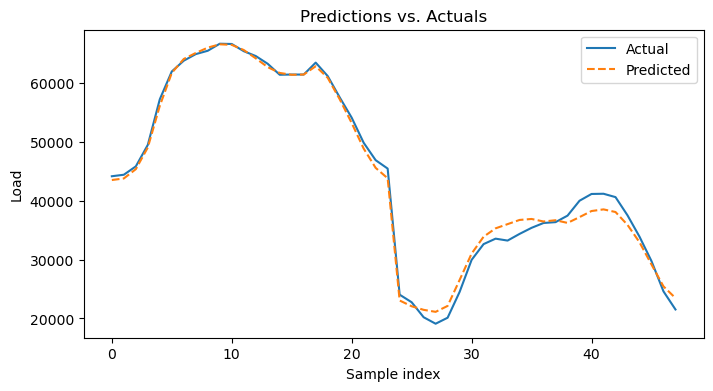

In [36]:
import matplotlib.pyplot as plt

# flatten to 1D series
y_true = actuals.flatten().cpu().numpy()
y_pred = preds.flatten().cpu().numpy()

plt.figure(figsize=(8,4))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.legend()
plt.title("Predictions vs. Actuals")
plt.xlabel("Sample index")
plt.ylabel("Load")
plt.show()


Text(0.5, 0.98, 'Encoder Self-Attention (horizon step 0)')

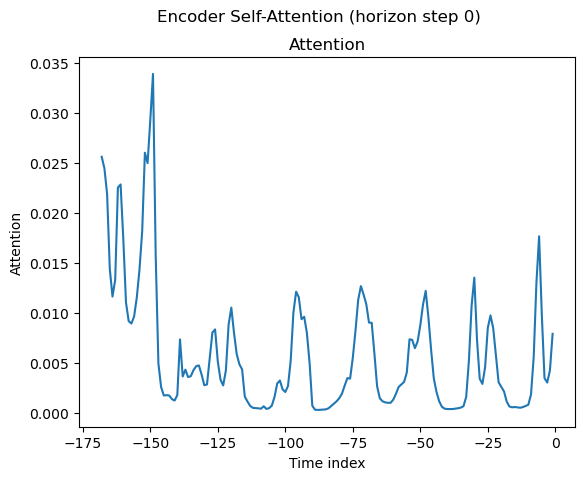

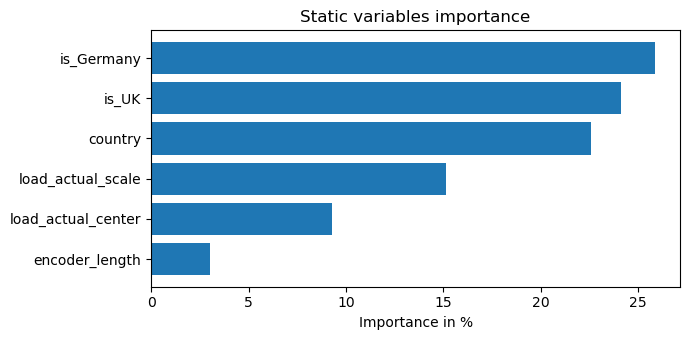

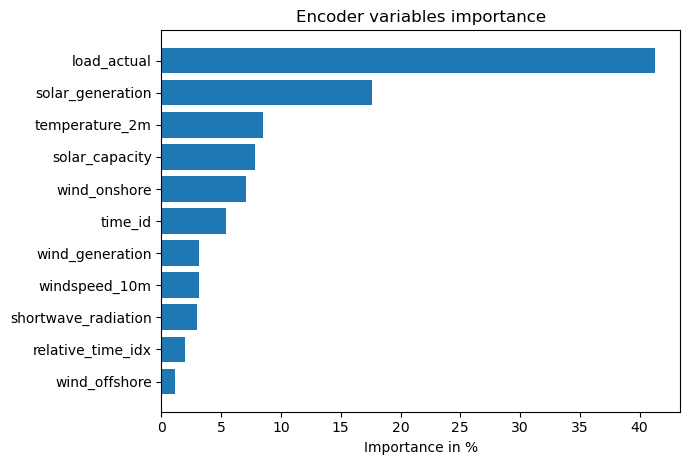

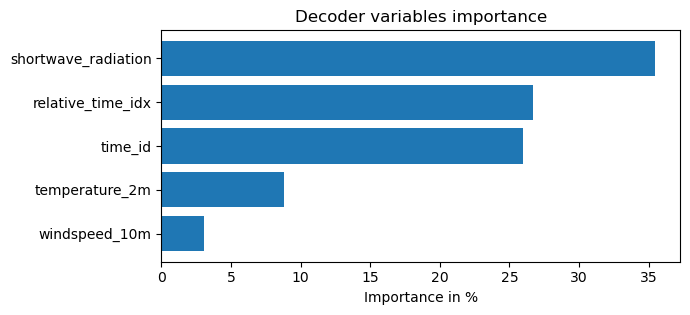

In [48]:
# 1) Grab a single batch from your validation loader
batch = next(iter(val_loader))
x, y = batch

# 2) Move everything to the same device
device = best_model.device
x = {k: v.to(device) for k, v in x.items()}

# 3) Get the raw forward outputs (dict with attention, gates, etc.)
best_model.eval()
with torch.no_grad():
    raw_output = best_model(x)   # this is exactly what 'mode="raw"' would return

# 4) Interpret that raw output
#    reduction can be "none" | "sum" | "mean"; attention_prediction_horizon picks
#    which forecast step’s attention you want to inspect (0 = first step)
interpretation = best_model.interpret_output(
    raw_output,
    reduction="mean",
    attention_prediction_horizon=0
)

# 5) Plot the interpretation figures
figures = best_model.plot_interpretation(interpretation)
# `figures` is a dict, e.g. {"Attention": fig1, "Variable selection": fig2, …}

# 6) Show the Attention heatmap
fig = figures['attention']
fig.suptitle("Encoder Self-Attention (horizon step 0)")


### Model Comparison

In [89]:
compare_df = combined_energy_data.sort_values("utc_timestamp").reset_index(drop=True)
compare_df.head()

,utc_timestamp,load_actual,solar_capacity,solar_generation,wind_generation,wind_onshore,wind_offshore,temperature_2m,shortwave_radiation,windspeed_10m,country,is_Germany,is_UK
0,2014-12-31 23:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,4.0,0.0,14.2,Germany,1,0
1,2014-12-31 23:00:00,26758.0,2664.0,13.0,782.0,664.0,117.0,4.7,0.0,20.3,UK,0,1
2,2015-01-01 00:00:00,41151.0,37248.0,71.0,8852.0,8336.0,517.0,3.8,0.0,14.4,Germany,1,0
3,2015-01-01 00:00:00,26758.0,2669.0,13.0,782.0,664.0,117.0,4.7,0.0,21.1,UK,0,1
4,2015-01-01 01:00:00,40135.0,37248.0,71.0,9054.0,8540.0,514.0,3.6,0.0,14.9,Germany,1,0


In [90]:
n = len(compare_df)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = compare_df.iloc[:train_end]
val_df   = compare_df.iloc[train_end:val_end]
test_df  = compare_df.iloc[val_end:]

In [91]:
FEATURE_COLS = [
    "solar_capacity", "solar_generation", "wind_generation",
    "wind_onshore", "wind_offshore",
    "temperature_2m", "shortwave_radiation", "windspeed_10m",
    "is_Germany", "is_UK"
]
TARGET_COL  = "load_actual"
INPUT_LEN   = 168   # e.g. last 24 hours
HORIZON     = 24    # 1‐step ahead

In [93]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, input_len, horizon, feature_cols, target_col):
        self.X = df[feature_cols].values.astype(np.float32)
        self.y = df[target_col].values.astype(np.float32)
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return len(self.X) - self.input_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.X[idx : idx + self.input_len]
        y = self.y[idx + self.input_len + self.horizon - 1]
        return torch.from_numpy(x), torch.tensor(y)

train_ds = TimeSeriesDataset(train_df, INPUT_LEN, HORIZON, FEATURE_COLS, TARGET_COL)
val_ds   = TimeSeriesDataset(val_df,   INPUT_LEN, HORIZON, FEATURE_COLS, TARGET_COL)
test_ds  = TimeSeriesDataset(test_df,  INPUT_LEN, HORIZON, FEATURE_COLS, TARGET_COL)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)
test_loader  = DataLoader(test_ds,  batch_size=64)

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, num_feats, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_feats,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.lstm(x)
        # take last time‐step
        out = out[:, -1, :]           # (batch, hidden_size)
        return self.linear(out).squeeze(1)

def train_model(model, loader, val_loader, epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float("inf")

    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()

        # validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
        avg_val = np.mean(val_losses)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), "best_lstm.pt")
        print(f"Epoch {ep+1}/{epochs} — val_loss: {avg_val:.4f}")
    # load best
    model.load_state_dict(torch.load("best_lstm.pt"))
    return model

# train LSTM
lstm = LSTMForecaster(num_feats=len(FEATURE_COLS))
lstm = train_model(lstm, train_loader, val_loader, epochs=20, lr=3e-4)

Epoch 1/20 — val_loss: 2190949524.7863
Epoch 2/20 — val_loss: 2189016101.7436
Epoch 3/20 — val_loss: 2187099093.3333
Epoch 4/20 — val_loss: 2185187599.3162
Epoch 5/20 — val_loss: 2183277611.2137
Epoch 6/20 — val_loss: 2181369764.6496
Epoch 7/20 — val_loss: 2179462296.0684
